In [1]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 3.7 MB/s eta 0:00:00


In [2]:
import pickle
import numpy as np

def load_subject(data_path, subject_id):
    """
    Load one WESAD subject pickle file.
    Returns chest signals, wrist signals, and labels.
    """
    path = f"{data_path}/S{subject_id}/S{subject_id}.pkl"
    
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    # Chest signals — sampled at 700 Hz
    chest = data['signal']['chest']
    # Wrist signals — sampled at various rates
    wrist = data['signal']['wrist']
    # Labels — sampled at 700 Hz, aligned with chest
    labels = data['label'].flatten()
    
    return chest, wrist, labels

# Test on subject 2
chest, wrist, labels = load_subject('/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD', subject_id=2)

print("Chest keys:", list(chest.keys()))
print("ECG shape:", chest['ECG'].shape)
print("Label shape:", labels.shape)
print("Unique labels:", np.unique(labels))
# Expected: [0, 1, 2, 3, 4]
# 0=transient, 1=baseline, 2=stress, 3=amusement, 4=meditation

Chest keys: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
ECG shape: (4255300, 1)
Label shape: (4255300,)
Unique labels: [0 1 2 3 4 6 7]


In [3]:
import neurokit2 as nk

def extract_rr_from_ecg(ecg_signal, fs=700):
    """
    Extract RR intervals from raw ECG using NeuroKit2.
    Returns RR intervals in ms and their timestamps in seconds.
    """
    # Clean ECG signal
    ecg_clean = nk.ecg_clean(ecg_signal.flatten(), sampling_rate=fs)
    
    # Detect R-peaks
    _, rpeaks_info = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
    rpeaks = rpeaks_info['ECG_R_Peaks']
    
    # Convert to RR intervals in milliseconds
    rr_ms = np.diff(rpeaks) * (1000.0 / fs)
    
    # Timestamps = midpoint between consecutive R-peaks, in seconds
    timestamps = (rpeaks[:-1] + rpeaks[1:]) / 2.0 / fs
    
    return rr_ms, timestamps, rpeaks

# Test
ecg = chest['ECG'].flatten()
rr_ms, timestamps, rpeaks = extract_rr_from_ecg(ecg, fs=700)

print(f"Number of beats detected: {len(rpeaks)}")
print(f"Number of RR intervals: {len(rr_ms)}")
print(f"Mean RR: {np.mean(rr_ms):.1f} ms  ({60000/np.mean(rr_ms):.1f} bpm)")
print(f"Recording duration: {timestamps[-1]/60:.1f} minutes")

Number of beats detected: 7250
Number of RR intervals: 7249
Mean RR: 838.4 ms  (71.6 bpm)
Recording duration: 101.3 minutes


In [4]:
def clean_rr(rr_ms, timestamps):
    """
    Remove physiologically impossible and artifactual RR intervals.
    """
    rr = rr_ms.copy().astype(float)
    ts = timestamps.copy()
    
    # 1. Physiological bounds (30–200 bpm)
    valid = (rr > 300) & (rr < 2000)
    rr[~valid] = np.nan
    
    # 2. Successive difference check — no >20% beat-to-beat change
    for i in range(1, len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]):
            if abs(rr[i] - rr[i-1]) / rr[i-1] > 0.20:
                rr[i] = np.nan
    
    # 3. Report how many were removed
    nan_pct = np.sum(np.isnan(rr)) / len(rr) * 100
    print(f"  Removed {nan_pct:.1f}% of RR intervals as artifacts")
    
    # 4. Linear interpolation for short gaps
    mask = np.isnan(rr)
    if mask.any():
        rr[mask] = np.interp(
            np.where(mask)[0],
            np.where(~mask)[0],
            rr[~mask]
        )
        
    
    return rr, ts



rr_ms_clean, timestamps_clean = clean_rr(rr_ms, timestamps)

  Removed 4.3% of RR intervals as artifacts


In [5]:
def assign_labels_to_rr(labels, rpeaks):
    """
    Assign a WESAD label to each RR interval.
    Uses majority vote of raw labels between consecutive R-peaks.
    """
    rr_labels = []
    
    for i in range(len(rpeaks) - 1):
        start = rpeaks[i]
        end   = rpeaks[i + 1]
        segment_labels = labels[start:end]
        
        # Majority vote — ignore transient label (0)
        valid_labels = segment_labels[segment_labels > 0]
        if len(valid_labels) == 0:
            rr_labels.append(0)  # transient
        else:
            majority = np.bincount(valid_labels).argmax()
            rr_labels.append(majority)
    
    return np.array(rr_labels)

rr_labels = assign_labels_to_rr(labels, rpeaks)
print("Label distribution:")
for l, name in zip([0,1,2,3,4],
                   ['transient','baseline','stress','amusement','meditation']):
    count = np.sum(rr_labels == l)
    print(f"  {name}: {count} beats ({count/len(rr_labels)*100:.1f}%)")

Label distribution:
  transient: 3658 beats (50.5%)
  baseline: 1384 beats (19.1%)
  stress: 790 beats (10.9%)
  amusement: 400 beats (5.5%)
  meditation: 862 beats (11.9%)


In [6]:
def map_to_4class(rr_ms, rr_labels):
    """
    Map WESAD 5-class labels to your 4 stress levels.
    
    WESAD label → Your class:
    0 (transient)  → discard
    1 (baseline)   → 0 (relaxed)
    3 (amusement)  → 0 (relaxed)
    4 (meditation) → 0 (relaxed)
    2 (stress)     → split by RMSSD into 1 (mild), 2 (moderate), 3 (high)
    """
    # Keep only non-transient beats
    keep = rr_labels > 0
    rr_clean   = rr_ms[keep]
    lab_clean  = rr_labels[keep]
    
    # Non-stress labels → relaxed (0)
    new_labels = np.zeros(len(lab_clean), dtype=int)
    
    # Stress beats → split by local RMSSD
    stress_idx = np.where(lab_clean == 2)[0]
    
    if len(stress_idx) > 0:
        stress_rr = rr_clean[stress_idx]
        
        # Compute local RMSSD in a 30-beat rolling window
        local_rmssd = []
        for i in range(len(stress_rr)):
            window = stress_rr[max(0, i-15):i+15]
            diff = np.diff(window)
            rmssd = np.sqrt(np.mean(diff**2)) if len(diff) > 0 else 50
            local_rmssd.append(rmssd)
        local_rmssd = np.array(local_rmssd)
        
        # Split by RMSSD percentiles
        # High RMSSD = mild stress, Low RMSSD = high stress
        p33 = np.percentile(local_rmssd, 33)
        p66 = np.percentile(local_rmssd, 66)
        
        for i, idx in enumerate(stress_idx):
            if local_rmssd[i] >= p66:
                new_labels[idx] = 1   # mild stress
            elif local_rmssd[i] >= p33:
                new_labels[idx] = 2   # moderate stress
            else:
                new_labels[idx] = 3   # high stress
    
    return rr_clean, new_labels

rr_final, labels_4class = map_to_4class(rr_ms_clean, rr_labels)

print("\n4-class distribution:")
for l, name in enumerate(['relaxed','mild','moderate','high']):
    count = np.sum(labels_4class == l)
    print(f"  {l} ({name}): {count} ({count/len(labels_4class)*100:.1f}%)")


4-class distribution:
  0 (relaxed): 2801 (78.0%)
  1 (mild): 269 (7.5%)
  2 (moderate): 260 (7.2%)
  3 (high): 261 (7.3%)


In [7]:
import os

SUBJECT_IDS = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
DATA_PATH   = '/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE_PATH   = '/kaggle/working/processed'
os.makedirs(SAVE_PATH, exist_ok=True)

all_subjects = {}

for sid in SUBJECT_IDS:
    print(f"\nProcessing S{sid}...")
    
    try:
        # Load
        chest, wrist, labels = load_subject(DATA_PATH, sid)
        
        # Extract RR
        ecg = chest['ECG'].flatten()
        rr_ms, timestamps, rpeaks = extract_rr_from_ecg(ecg, fs=700)
        
        # Clean
        rr_clean, ts_clean = clean_rr(rr_ms, timestamps)
        
        # Assign labels
        rr_labels = assign_labels_to_rr(labels, rpeaks)
        
        # Map to 4-class
        rr_final, labels_4class = map_to_4class(rr_clean, rr_labels)
        
        all_subjects[f'S{sid}'] = {
            'rr_ms':      rr_final,
            'timestamps': ts_clean[:len(rr_final)],
            'labels':     labels_4class,
        }
        
        print(f"  S{sid} done — {len(rr_final)} beats")
        
    except Exception as e:
        print(f"  S{sid} FAILED: {e}")

# Save everything to disk — do this once, load forever after
import pickle
with open(f'/kaggle/working/processed/wesad_processed.pkl', 'wb') as f:
    pickle.dump(all_subjects, f)

print("\nAll subjects saved to wesad_processed.pkl")


Processing S1...
  S1 FAILED: [Errno 2] No such file or directory: '/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD/S1/S1.pkl'

Processing S2...
  Removed 4.3% of RR intervals as artifacts
  S2 done — 3591 beats

Processing S3...
  Removed 5.7% of RR intervals as artifacts
  S3 done — 3177 beats

Processing S4...
  Removed 1.8% of RR intervals as artifacts
  S4 done — 3398 beats

Processing S5...
  Removed 0.2% of RR intervals as artifacts
  S5 done — 3695 beats

Processing S6...
  Removed 0.6% of RR intervals as artifacts
  S6 done — 3711 beats

Processing S7...
  Removed 3.6% of RR intervals as artifacts
  S7 done — 3626 beats

Processing S8...
  Removed 1.9% of RR intervals as artifacts
  S8 done — 3938 beats

Processing S9...
  Removed 0.5% of RR intervals as artifacts
  S9 done — 4106 beats

Processing S10...
  Removed 0.7% of RR intervals as artifacts
  S10 done — 4943 beats

Processing S11...
  Removed 0.5% of RR intervals as artifacts
  S11 d

In [8]:
import pickle
import numpy as np

SAVE_PATH = '/kaggle/working/processed'

with open(f'{SAVE_PATH}/wesad_processed.pkl', 'rb') as f:
    all_subjects = pickle.load(f)

print("Subjects loaded:", list(all_subjects.keys()))
print("Keys per subject:", list(all_subjects['S2'].keys()))
# Should show: rr_ms, timestamps, labels

Subjects loaded: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
Keys per subject: ['rr_ms', 'timestamps', 'labels']


In [9]:
def create_windows(rr_ms, labels, window_size=60, step=10):
    """
    Slice RR stream into overlapping windows.
    window_size = 60 beats (~1 min at average HR)
    step        = 10 beats overlap
    """
    X_windows = []
    y_windows = []

    for start in range(0, len(rr_ms) - window_size, step):
        window = rr_ms[start:start + window_size]
        window_labels = labels[start:start + window_size]

        # Majority label for this window
        majority = np.bincount(window_labels).argmax()

        X_windows.append(window)
        y_windows.append(majority)

    return np.array(X_windows), np.array(y_windows)

# Test on S2
d = all_subjects['S2']
X_win, y_win = create_windows(d['rr_ms'], d['labels'])

print(f"Windows created : {len(X_win)}")
print(f"Window shape    : {X_win.shape}")  # (n_windows, 60)
print(f"Label distribution:")
for l, name in enumerate(['relaxed','mild','moderate','high']):
    n = np.sum(y_win == l)
    print(f"  {l} ({name}): {n} ({n/len(y_win)*100:.1f}%)")

Windows created : 354
Window shape    : (354, 60)
Label distribution:
  0 (relaxed): 276 (78.0%)
  1 (mild): 30 (8.5%)
  2 (moderate): 25 (7.1%)
  3 (high): 23 (6.5%)


In [10]:
from scipy.signal import welch

def extract_hrv_features(rr_window, fs_resample=4.0):
    """
    Extract 13 HRV features from one RR window.
    Returns a flat feature vector.
    """
    rr   = np.array(rr_window)
    diff = np.diff(rr)

    # --- Time domain ---
    mean_rr = np.mean(rr)
    sdnn    = np.std(rr)
    rmssd   = np.sqrt(np.mean(diff**2))
    pnn50   = np.sum(np.abs(diff) > 50) / len(diff) * 100
    cv_rr   = sdnn / mean_rr        # coefficient of variation

    # --- Frequency domain ---
    # Resample RR to uniform time grid at 4 Hz
    times     = np.cumsum(rr) / 1000.0
    uniform_t = np.arange(0, times[-1], 1.0 / fs_resample)
    rr_uniform = np.interp(uniform_t, times, rr)

    freqs, psd = welch(rr_uniform, fs=fs_resample,
                       nperseg=min(256, len(rr_uniform)))

    vlf   = np.trapz(psd[(freqs >= 0.003) & (freqs < 0.04)])
    lf    = np.trapz(psd[(freqs >= 0.04)  & (freqs < 0.15)])
    hf    = np.trapz(psd[(freqs >= 0.15)  & (freqs < 0.40)])
    lf_hf = lf / (hf + 1e-8)
    lf_nu = lf / (lf + hf + 1e-8)   # normalised LF

    # --- Non-linear (Poincaré) ---
    sd1 = np.sqrt(0.5) * np.std(diff)
    sd2 = np.sqrt(max(2 * sdnn**2 - 0.5 * np.var(diff), 0))
    sd_ratio = sd1 / (sd2 + 1e-8)

    return np.array([
        mean_rr, sdnn, rmssd, pnn50, cv_rr,
        vlf, lf, hf, lf_hf, lf_nu,
        sd1, sd2, sd_ratio
    ])

FEATURE_NAMES = [
    'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'cv_rr',
    'vlf', 'lf', 'hf', 'lf_hf', 'lf_nu',
    'sd1', 'sd2', 'sd_ratio'
]

# Test on one window
features = extract_hrv_features(X_win[0])
print("Feature vector length:", len(features))
for name, val in zip(FEATURE_NAMES, features):
    print(f"  {name:12s}: {val:.4f}")

Feature vector length: 13
  mean_rr     : 721.7262
  sdnn        : 84.6020
  rmssd       : 50.4410
  pnn50       : 23.7288
  cv_rr       : 0.1172
  vlf         : 0.0000
  lf          : 181747.3088
  hf          : 34301.9378
  lf_hf       : 5.2985
  lf_nu       : 0.8412
  sd1         : 35.6630
  sd2         : 114.2067
  sd_ratio    : 0.3123


/tmp/ipykernel_16/1386776573.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  vlf   = np.trapz(psd[(freqs >= 0.003) & (freqs < 0.04)])
/tmp/ipykernel_16/1386776573.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf    = np.trapz(psd[(freqs >= 0.04)  & (freqs < 0.15)])
/tmp/ipykernel_16/1386776573.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf    = np.trapz(psd[(freqs >= 0.15)  & (freqs < 0.40)])


In [11]:
def get_circadian_features(unix_timestamp):
    """
    5 circadian features from a window's timestamp.
    """
    t    = unix_timestamp % 86400   # seconds since midnight
    hour = t / 3600.0

    sin_24h = np.sin(2 * np.pi * t / 86400)
    cos_24h = np.cos(2 * np.pi * t / 86400)
    sin_90m = np.sin(2 * np.pi * t / 5400)    # ultradian 90-min
    cos_90m = np.cos(2 * np.pi * t / 5400)

    # Cortisol proxy — peaks ~8AM, secondary ~3PM
    cortisol = (
        0.6 * np.exp(-0.5 * ((hour - 8)  / 1.5) ** 2) +
        0.3 * np.exp(-0.5 * ((hour - 15) / 1.5) ** 2)
    )

    return np.array([sin_24h, cos_24h, sin_90m, cos_90m, cortisol])

CIRCADIAN_NAMES = ['sin_24h','cos_24h','sin_90m','cos_90m','cortisol']

In [12]:
from tqdm import tqdm  # pip install tqdm — shows a progress bar

def build_feature_matrix(all_subjects, window_size=60, step=10):
    """
    Build complete feature matrix across all subjects.
    Returns X (features), y (labels), groups (subject IDs for LOSO-CV).
    """
    X_all      = []
    y_all      = []
    groups_all = []

    for sid, d in tqdm(all_subjects.items()):
        rr_ms      = d['rr_ms']
        labels     = d['labels']
        timestamps = d['timestamps']

        X_win, y_win = create_windows(rr_ms, labels,
                                      window_size=window_size,
                                      step=step)

        for i, (window, label) in enumerate(zip(X_win, y_win)):
            # HRV features
            try:
                hvr_feat = extract_hrv_features(window)
            except Exception:
                continue   # skip bad windows

            # Circadian features — use midpoint timestamp of window
            beat_idx = i * step + window_size // 2
            beat_idx = min(beat_idx, len(timestamps) - 1)
            ts       = timestamps[beat_idx]
            circ_feat = get_circadian_features(ts)

            # Concatenate into one flat vector
            full_feat = np.concatenate([hvr_feat, circ_feat])

            X_all.append(full_feat)
            y_all.append(label)
            groups_all.append(int(sid[1:]))   # S2 → 2

    X = np.array(X_all)
    y = np.array(y_all)
    groups = np.array(groups_all)

    print(f"\nFeature matrix shape : {X.shape}")
    print(f"Labels shape         : {y.shape}")
    print(f"Subjects represented : {np.unique(groups)}")
    print(f"\nClass distribution:")
    for l, name in enumerate(['relaxed','mild','moderate','high']):
        n = np.sum(y == l)
        print(f"  {l} ({name}): {n} ({n/len(y)*100:.1f}%)")

    return X, y, groups

X, y, groups = build_feature_matrix(all_subjects)

# Save the feature matrix — you'll reuse this for every experiment
np.save(f'{SAVE_PATH}/X_features.npy', X)
np.save(f'{SAVE_PATH}/y_labels.npy',   y)
np.save(f'{SAVE_PATH}/groups.npy',     groups)
print("\nFeature matrix saved.")

  0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_16/1386776573.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  vlf   = np.trapz(psd[(freqs >= 0.003) & (freqs < 0.04)])
/tmp/ipykernel_16/1386776573.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf    = np.trapz(psd[(freqs >= 0.04)  & (freqs < 0.15)])
/tmp/ipykernel_16/1386776573.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf    = np.trapz(psd[(freqs >= 0.15)  & (freqs < 0.40)])
100%|██████████| 15/15 [00:03<00:00,  3.84it/s]


Feature matrix shape : (6016, 18)
Labels shape         : (6016,)
Subjects represented : [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17]

Class distribution:
  0 (relaxed): 4404 (73.2%)
  1 (mild): 650 (10.8%)
  2 (moderate): 444 (7.4%)
  3 (high): 518 (8.6%)

Feature matrix saved.


In [13]:
print(f"Any NaN    : {np.isnan(X).any()}")
print(f"Any Inf    : {np.isinf(X).any()}")
print(f"Feature means:\n")
all_names = FEATURE_NAMES + CIRCADIAN_NAMES
for name, mean, std in zip(all_names, X.mean(axis=0), X.std(axis=0)):
    print(f"  {name:12s}: mean={mean:8.3f}  std={std:7.3f}")

Any NaN    : False
Any Inf    : False
Feature means:

  mean_rr     : mean= 775.202  std=154.443
  sdnn        : mean=  67.932  std= 33.956
  rmssd       : mean=  44.143  std= 26.178
  pnn50       : mean=  22.416  std= 19.323
  cv_rr       : mean=   0.086  std=  0.038
  vlf         : mean=17212.428  std=44893.529
  lf          : mean=122618.705  std=183999.463
  hf          : mean=37343.662  std=50166.790
  lf_hf       : mean=   6.627  std= 10.547
  lf_nu       : mean=   0.728  std=  0.193
  sd1         : mean=  31.182  std= 18.507
  sd2         : mean=  90.311  std= 45.438
  sd_ratio    : mean=   0.341  std=  0.129
  sin_24h     : mean=   0.117  std=  0.065
  cos_24h     : mean=   0.991  std=  0.008
  sin_90m     : mean=   0.508  std=  0.426
  cos_90m     : mean=  -0.171  std=  0.728
  cortisol    : mean=   0.000  std=  0.000


In [14]:
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, cohen_kappa_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

SAVE_PATH = '/kaggle/working/processed'

X      = np.load(f'{SAVE_PATH}/X_features.npy')
y      = np.load(f'{SAVE_PATH}/y_labels.npy')
groups = np.load(f'{SAVE_PATH}/groups.npy')

print(f"X shape      : {X.shape}")
print(f"y shape      : {y.shape}")
print(f"Subjects     : {np.unique(groups)}")
print(f"Class counts : {np.bincount(y.astype(int))}")

X shape      : (6016, 18)
y shape      : (6016,)
Subjects     : [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17]
Class counts : [4404  650  444  518]


In [15]:
CLASS_NAMES = ['relaxed', 'mild', 'moderate', 'high']
logo        = LeaveOneGroupOut()

# Storage for results
all_y_true  = []
all_y_pred  = []
subject_f1s = {}

print("Starting LOSO-CV...\n")

for fold, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups)):

    test_subject = np.unique(groups[test_idx])[0]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit scaler on training data only — never on test
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Per-sample weights to handle class imbalance
    sample_weights = compute_sample_weight('balanced', y_train)

    # XGBoost multiclass
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        verbose=False
    )

    y_pred = model.predict(X_test)

    # Store results
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # Per-subject F1
    subj_f1 = f1_score(y_test, y_pred, average='macro',
                       zero_division=0)
    subject_f1s[f'S{test_subject}'] = subj_f1

    print(f"S{test_subject:02d} — macro F1: {subj_f1:.3f}")

print("\nLOSO-CV complete.")

Starting LOSO-CV...

S02 — macro F1: 0.303
S03 — macro F1: 0.478
S04 — macro F1: 0.364
S05 — macro F1: 0.413
S06 — macro F1: 0.451
S07 — macro F1: 0.511
S08 — macro F1: 0.418
S09 — macro F1: 0.340
S10 — macro F1: 0.569
S11 — macro F1: 0.601
S13 — macro F1: 0.552
S14 — macro F1: 0.715
S15 — macro F1: 0.447
S16 — macro F1: 0.627
S17 — macro F1: 0.618

LOSO-CV complete.


In [16]:
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

print("\n" + "="*50)
print("OVERALL RESULTS — XGBoost Baseline")
print("="*50)

# Per-class report
print("\nPer-class Classification Report:")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0
))

# Summary metrics
macro_f1 = f1_score(all_y_true, all_y_pred,
                    average='macro', zero_division=0)
kappa    = cohen_kappa_score(all_y_true, all_y_pred,
                             weights='quadratic')
accuracy = np.mean(all_y_true == all_y_pred)

print(f"Overall Accuracy       : {accuracy:.3f}")
print(f"Macro F1               : {macro_f1:.3f}")
print(f"Quadratic Weighted Kappa: {kappa:.3f}")

# Per-subject breakdown
print("\nPer-subject Macro F1:")
for sid, f1 in sorted(subject_f1s.items()):
    bar = '█' * int(f1 * 20)
    print(f"  {sid}: {f1:.3f}  {bar}")

mean_f1 = np.mean(list(subject_f1s.values()))
std_f1  = np.std(list(subject_f1s.values()))
print(f"\n  Mean ± Std : {mean_f1:.3f} ± {std_f1:.3f}")


OVERALL RESULTS — XGBoost Baseline

Per-class Classification Report:
              precision    recall  f1-score   support

     relaxed      0.911     0.890     0.901      4404
        mild      0.424     0.489     0.454       650
    moderate      0.372     0.351     0.362       444
        high      0.470     0.492     0.481       518

    accuracy                          0.773      6016
   macro avg      0.544     0.556     0.549      6016
weighted avg      0.781     0.773     0.776      6016

Overall Accuracy       : 0.773
Macro F1               : 0.549
Quadratic Weighted Kappa: 0.599

Per-subject Macro F1:
  S10: 0.569  ███████████
  S11: 0.601  ████████████
  S13: 0.552  ███████████
  S14: 0.715  ██████████████
  S15: 0.447  ████████
  S16: 0.627  ████████████
  S17: 0.618  ████████████
  S2: 0.303  ██████
  S3: 0.478  █████████
  S4: 0.364  ███████
  S5: 0.413  ████████
  S6: 0.451  █████████
  S7: 0.511  ██████████
  S8: 0.418  ████████
  S9: 0.340  ██████

  Mean ± Std : 0.

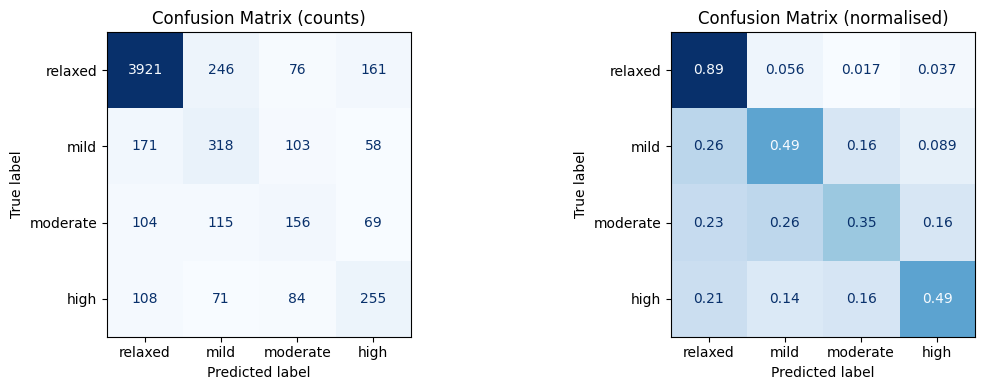

Saved confusion matrix.


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm   = confusion_matrix(all_y_true, all_y_pred)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalised

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (counts)')

# Normalised
ConfusionMatrixDisplay(cm_n, display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (normalised)')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/confusion_matrix_xgboost.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion matrix.")

In [18]:
# Save model and scaler — you'll need these for comparison later
import joblib

joblib.dump(model,  f'{SAVE_PATH}/xgboost_baseline.pkl')
joblib.dump(scaler, f'{SAVE_PATH}/scaler_baseline.pkl')
print("Model and scaler saved.")

Model and scaler saved.


In [19]:
from scipy.optimize import curve_fit

def cosinor_model(t_hours, mesor, amplitude, acrophase):
    """
    Single-component Cosinor model.
    t_hours   = time of day in hours (0–24)
    mesor     = mean level of rhythm
    amplitude = half the range of oscillation  
    acrophase = time of peak in radians
    """
    return mesor + amplitude * np.cos(
        (2 * np.pi / 24.0) * t_hours + acrophase
    )

def fit_cosinor_subject(rr_ms, timestamps):
    """
    Fit Cosinor model to a subject's full RR recording.
    Returns fitted parameters and residuals.
    """
    # Convert timestamps to hours of day
    t_hours = (timestamps % 86400) / 3600.0

    # Initial guess: mesor=mean RR, amplitude=50ms, acrophase=-1.5
    p0 = [np.mean(rr_ms), 50.0, -1.5]

    try:
        popt, _ = curve_fit(
            cosinor_model,
            t_hours,
            rr_ms,
            p0=p0,
            maxfev=10000
        )
        mesor, amplitude, acrophase = popt

        # Predicted circadian baseline at each beat
        baseline = cosinor_model(t_hours, *popt)

        # Residual = actual RR − circadian baseline
        # This is what your ML model uses
        residual = rr_ms - baseline

        # R-squared — how well does Cosinor explain the variance
        ss_res  = np.sum((rr_ms - baseline) ** 2)
        ss_tot  = np.sum((rr_ms - np.mean(rr_ms)) ** 2)
        r2      = 1 - (ss_res / ss_tot)

        return {
            'mesor'     : mesor,
            'amplitude' : amplitude,
            'acrophase' : acrophase,
            'baseline'  : baseline,
            'residual'  : residual,
            'r2'        : r2
        }

    except RuntimeError:
        print("  Cosinor fit failed — using mean as baseline")
        baseline = np.full_like(rr_ms, np.mean(rr_ms))
        return {
            'mesor'     : np.mean(rr_ms),
            'amplitude' : 0.0,
            'acrophase' : 0.0,
            'baseline'  : baseline,
            'residual'  : rr_ms - baseline,
            'r2'        : 0.0
        }

In [20]:
cosinor_fits = {}

print("Fitting Cosinor models...\n")
for sid, d in all_subjects.items():
    fit = fit_cosinor_subject(d['rr_ms'], d['timestamps'])
    cosinor_fits[sid] = fit
    print(f"{sid}: mesor={fit['mesor']:.1f}ms  "
          f"amplitude={fit['amplitude']:.1f}ms  "
          f"R²={fit['r2']:.3f}")

# Save fits
with open(f'{SAVE_PATH}/cosinor_fits.pkl', 'wb') as f:
    pickle.dump(cosinor_fits, f)
print("\nCosinor fits saved.")

Fitting Cosinor models...

S2: mesor=12993.5ms  amplitude=12186.8ms  R²=0.170
S3: mesor=75743.0ms  amplitude=74916.5ms  R²=0.301
S4: mesor=5008.8ms  amplitude=-4177.2ms  R²=0.162
S5: mesor=14558.3ms  amplitude=-13753.8ms  R²=0.273
S6: mesor=20428.5ms  amplitude=19615.7ms  R²=0.142
S7: mesor=-9735.8ms  amplitude=-10621.6ms  R²=0.025
S8: mesor=5546.8ms  amplitude=-4799.3ms  R²=0.143
S9: mesor=8075.7ms  amplitude=7317.2ms  R²=0.029
S10: mesor=-4577.2ms  amplitude=5249.7ms  R²=0.033
S11: mesor=47191.6ms  amplitude=-46602.9ms  R²=0.317
S13: mesor=10213.3ms  amplitude=-9560.9ms  R²=0.042
S14: mesor=60951.6ms  amplitude=-60376.5ms  R²=0.455
S15: mesor=8644.5ms  amplitude=7915.0ms  R²=0.137
S16: mesor=72498.8ms  amplitude=-71920.9ms  R²=0.475
S17: mesor=22670.2ms  amplitude=-21990.0ms  R²=0.227

Cosinor fits saved.


In [21]:
def extract_residual_features(residual_window):
    """
    5 features derived from the Cosinor residual within a window.
    These capture how much the current HRV deviates from
    the expected circadian baseline.
    """
    r = np.array(residual_window)

    res_mean  = np.mean(r)       # average deviation from baseline
    res_std   = np.std(r)        # variability of deviation
    res_max   = np.max(np.abs(r))# peak deviation
    res_trend = np.polyfit(       # is deviation increasing or decreasing?
        np.arange(len(r)), r, 1)[0]
    res_energy = np.sum(r**2) / len(r)  # energy of deviation

    return np.array([res_mean, res_std, res_max,
                     res_trend, res_energy])

RESIDUAL_NAMES = [
    'res_mean', 'res_std', 'res_max',
    'res_trend', 'res_energy'
]

In [22]:
from tqdm import tqdm

def build_feature_matrix_with_cosinor(all_subjects, cosinor_fits,
                                       window_size=60, step=10):
    X_all      = []
    y_all      = []
    groups_all = []

    for sid, d in tqdm(all_subjects.items()):
        rr_ms      = d['rr_ms']
        labels     = d['labels']
        timestamps = d['timestamps']
        residual   = cosinor_fits[sid]['residual']
        mesor      = cosinor_fits[sid]['mesor']
        amplitude  = cosinor_fits[sid]['amplitude']

        X_win, y_win = create_windows(rr_ms, labels,
                                      window_size, step)
        # Also window the residual
        res_windows, _ = create_windows(residual, labels,
                                        window_size, step)

        for i, (window, res_win, label) in enumerate(
                zip(X_win, res_windows, y_win)):
            try:
                # Original HRV features
                hrv_feat  = extract_hrv_features(window)

                # Cosinor residual features (your novelty)
                res_feat  = extract_residual_features(res_win)

                # Cosinor model parameters for this subject
                cos_params = np.array([mesor, amplitude])

                # Circadian time features
                beat_idx  = min(i * step + window_size // 2,
                                len(timestamps) - 1)
                circ_feat = get_circadian_features(timestamps[beat_idx])

                # Full feature vector
                full_feat = np.concatenate([
                    hrv_feat,    # 13 features
                    res_feat,    # 5 features  ← Cosinor residuals
                    cos_params,  # 2 features  ← subject's rhythm params
                    circ_feat    # 5 features
                ])               # = 25 total

                X_all.append(full_feat)
                y_all.append(label)
                groups_all.append(int(sid[1:]))

            except Exception:
                continue

    X = np.array(X_all)
    y = np.array(y_all)
    groups = np.array(groups_all)

    print(f"Feature matrix shape : {X.shape}")
    print(f"Features per window  : {X.shape[1]}")
    print(f"  HRV features       : 13")
    print(f"  Cosinor residuals  : 5  ← your novelty")
    print(f"  Cosinor params     : 2")
    print(f"  Circadian time     : 5")

    return X, y, groups

X_cos, y_cos, groups_cos = build_feature_matrix_with_cosinor(
    all_subjects, cosinor_fits
)

np.save(f'{SAVE_PATH}/X_cosinor.npy', X_cos)
np.save(f'{SAVE_PATH}/y_cosinor.npy', y_cos)
print("\nCosinor feature matrix saved.")

100%|██████████| 15/15 [00:05<00:00,  2.97it/s]

Feature matrix shape : (6016, 25)
Features per window  : 25
  HRV features       : 13
  Cosinor residuals  : 5  ← your novelty
  Cosinor params     : 2
  Circadian time     : 5

Cosinor feature matrix saved.


In [23]:
all_y_true_cos  = []
all_y_pred_cos  = []
subject_f1s_cos = {}

print("Training XGBoost + Cosinor features...\n")

for fold, (train_idx, test_idx) in enumerate(
        logo.split(X_cos, y_cos, groups_cos)):

    test_subject = np.unique(groups_cos[test_idx])[0]

    X_train, X_test = X_cos[train_idx], X_cos[test_idx]
    y_train, y_test = y_cos[train_idx], y_cos[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    sample_weights = compute_sample_weight('balanced', y_train)

    model_cos = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )

    model_cos.fit(X_train, y_train,
                  sample_weight=sample_weights,
                  verbose=False)

    y_pred = model_cos.predict(X_test)
    all_y_true_cos.extend(y_test)
    all_y_pred_cos.extend(y_pred)

    subj_f1 = f1_score(y_test, y_pred, average='macro',
                       zero_division=0)
    subject_f1s_cos[f'S{test_subject}'] = subj_f1
    print(f"S{test_subject:02d} — macro F1: {subj_f1:.3f}")

Training XGBoost + Cosinor features...

S02 — macro F1: 0.552
S03 — macro F1: 0.600
S04 — macro F1: 0.487
S05 — macro F1: 0.453
S06 — macro F1: 0.501
S07 — macro F1: 0.557
S08 — macro F1: 0.476
S09 — macro F1: 0.327
S10 — macro F1: 0.514
S11 — macro F1: 0.757
S13 — macro F1: 0.798
S14 — macro F1: 0.852
S15 — macro F1: 0.316
S16 — macro F1: 0.836
S17 — macro F1: 0.641


In [24]:
all_y_true_cos = np.array(all_y_true_cos)
all_y_pred_cos = np.array(all_y_pred_cos)

macro_f1_cos = f1_score(all_y_true_cos, all_y_pred_cos,
                        average='macro', zero_division=0)
kappa_cos    = cohen_kappa_score(all_y_true_cos, all_y_pred_cos,
                                 weights='quadratic')
acc_cos      = np.mean(all_y_true_cos == all_y_pred_cos)

print("\n" + "="*55)
print("ABLATION — XGBoost: HRV only vs HRV + Cosinor")
print("="*55)
print(f"{'Metric':<28} {'HRV only':>10} {'+ Cosinor':>10} {'Delta':>8}")
print("-"*55)
print(f"{'Accuracy':<28} {0.773:>10.3f} {acc_cos:>10.3f} "
      f"{acc_cos-0.773:>+8.3f}")
print(f"{'Macro F1':<28} {0.549:>10.3f} {macro_f1_cos:>10.3f} "
      f"{macro_f1_cos-0.549:>+8.3f}")
print(f"{'Quadratic Kappa':<28} {0.599:>10.3f} {kappa_cos:>10.3f} "
      f"{kappa_cos-0.599:>+8.3f}")

print("\nPer-class F1 comparison:")
report_cos = classification_report(
    all_y_true_cos, all_y_pred_cos,
    target_names=CLASS_NAMES,
    output_dict=True, zero_division=0
)
baseline_f1s = {'relaxed':0.901,'mild':0.454,
                'moderate':0.362,'high':0.481}
for cls in CLASS_NAMES:
    old = baseline_f1s[cls]
    new = report_cos[cls]['f1-score']
    print(f"  {cls:<10}: {old:.3f} → {new:.3f}  ({new-old:+.3f})")


ABLATION — XGBoost: HRV only vs HRV + Cosinor
Metric                         HRV only  + Cosinor    Delta
-------------------------------------------------------
Accuracy                          0.773      0.842   +0.069
Macro F1                          0.549      0.628   +0.079
Quadratic Kappa                   0.599      0.769   +0.170

Per-class F1 comparison:
  relaxed   : 0.901 → 0.952  (+0.051)
  mild      : 0.454 → 0.549  (+0.095)
  moderate  : 0.362 → 0.392  (+0.030)
  high      : 0.481 → 0.617  (+0.136)


In [25]:
import numpy as np
# Load the cosinor feature matrix
X_cos    = np.load(f'{SAVE_PATH}/X_cosinor.npy')
y_cos    = np.load(f'{SAVE_PATH}/y_cosinor.npy')
groups_cos = np.load(f'{SAVE_PATH}/groups.npy')  # same groups as before

print(f"X_cos shape : {X_cos.shape}")
print(f"y_cos shape : {y_cos.shape}")

X_cos shape : (6016, 25)
y_cos shape : (6016,)
